<a href="https://colab.research.google.com/github/anuskasthapit98/Machine-Learning/blob/practice/Week9_Outliers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1️⃣ Z-Score Method (Statistical)


In [ ]:
import numpy as np

# Sample dataset (exam scores)
data = np.array([0, 70, 85, 88, 92, 95, 100, 120, 180])

# Known population mean and standard deviation
mean = 92.14
std_dev = 12.46

# Calculate Z-scores
z_scores = (data - mean) / std_dev

print("Data points:", data)
print("Z-scores:", np.round(z_scores, 2))

# Threshold for outlier detection
threshold = 2

# Identify outliers
outlier_indices = np.where(np.abs(z_scores) > threshold)
outliers = data[outlier_indices]

print(f"\nOutliers (|z| > {threshold}): {outliers}")

Data points: [  0  70  85  88  92  95 100 120 180]
Z-scores: [-7.39 -1.78 -0.57 -0.33 -0.01  0.23  0.63  2.24  7.05]

Outliers (|z| > 2): [  0 120 180]


2️⃣ Interquartile Range (IQR) Method

In [ ]:
import numpy as np

# Same dataset
data = np.array([0, 70, 85, 88, 92, 95, 100, 120, 180])

# Calculate quartiles
q1 = np.percentile(data, 25)
q3 = np.percentile(data, 75)
iqr = q3 - q1

print(f"Q1 (25th percentile): {q1}")
print(f"Q3 (75th percentile): {q3}")
print(f"IQR: {iqr}")

# Define fences
threshold = 1.5
lower_fence = q1 - threshold * iqr
upper_fence = q3 + threshold * iqr

print(f"\nLower Fence: {lower_fence}")
print(f"Upper Fence: {upper_fence}")

# Detect outliers
outliers = data[(data < lower_fence) | (data > upper_fence)]

print(f"\nOutliers (outside fences): {outliers}")

Q1 (25th percentile): 85.0
Q3 (75th percentile): 100.0
IQR: 15.0

Lower Fence: 62.5
Upper Fence: 122.5

Outliers (outside fences): [  0 180]


3️⃣ Local Outlier Factor (LOF)


Score for each point (+1 = normal, -1 = outlier):
Point 0: [1. 2.] -> Normal
Point 1: [1.5 1.8] -> Normal
Point 2: [5. 8.] -> OUTLIER
Point 3: [8. 8.] -> Normal
Point 4: [1.  0.6] -> Normal
Point 5: [ 9. 11.] -> Normal

Outlier coordinates: [[5. 8.]]


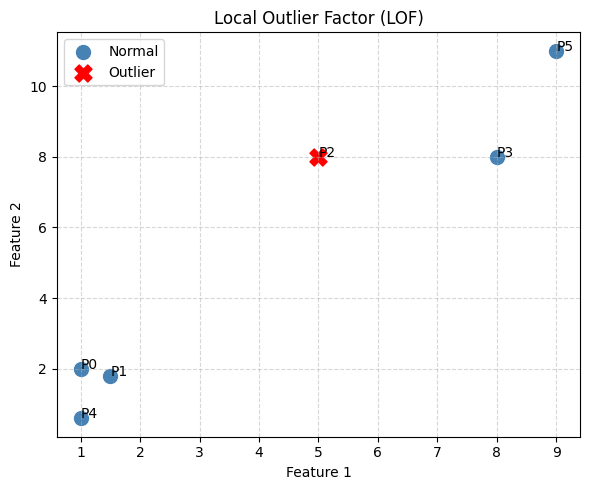

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import LocalOutlierFactor

# 2D dataset
X = np.array([
    [1, 2],
    [1.5, 1.8],
    [5, 8],
    [8, 8],
    [1, 0.6],
    [9, 11]
])

# LOF parameters
n_neighbors = 5
contamination = 0.1

# Fit LOF model
lof_model = LocalOutlierFactor(
    n_neighbors=n_neighbors,
    contamination=contamination
)
scores = lof_model.fit_predict(X)

# Extract outliers
outlier_indices = np.where(scores == -1)[0]
outliers = X[outlier_indices]

print("Score for each point (+1 = normal, -1 = outlier):")
for i, (point, score) in enumerate(zip(X, scores)):
    label = "OUTLIER" if score == -1 else "Normal"
    print(f"Point {i}: {point} -> {label}")

print(f"\nOutlier coordinates: {outliers}")

# Visualization
plt.figure(figsize=(6, 5))
plt.scatter(X[scores == 1, 0], X[scores == 1, 1],
            c='steelblue', s=100, label='Normal')
plt.scatter(X[scores == -1, 0], X[scores == -1, 1],
            c='red', s=150, marker='X', label='Outlier')

for i, point in enumerate(X):
    plt.annotate(f"P{i}", point)

plt.title("Local Outlier Factor (LOF)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

4️⃣ Isolation Forest
Load Data & Train Model

In [ ]:
from sklearn.ensemble import IsolationForest
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_iris
import numpy as np

# Load Iris dataset
iris = load_iris()
X = iris.data
y = iris.target  # NOT used for training

# Train–test split
X_train, X_test, _, _ = train_test_split(
    X, y, test_size=0.3, random_state=605
)

print(f"Training samples: {X_train.shape[0]}")
print(f"Test samples: {X_test.shape[0]}")
print(f"Features per sample: {X_train.shape[1]}")

# Train Isolation Forest
clf = IsolationForest(contamination=0.1)
clf.fit(X_train)


Training samples: 105
Test samples: 45
Features per sample: 4


IsolationForest(contamination=0.1)

Predictions

In [ ]:
# Predictions
y_pred_train = clf.predict(X_train)
y_pred_test = clf.predict(X_test)

print("=== Training Set ===")
print(f"Normal points: {np.sum(y_pred_train == 1)}")
print(f"Outliers: {np.sum(y_pred_train == -1)}")

print("\n=== Test Set ===")
print(f"Normal points: {np.sum(y_pred_test == 1)}")
print(f"Outliers: {np.sum(y_pred_test == -1)}")

=== Training Set ===
Normal points: 94
Outliers: 11

=== Test Set ===
Normal points: 40
Outliers: 5


Visualization Function

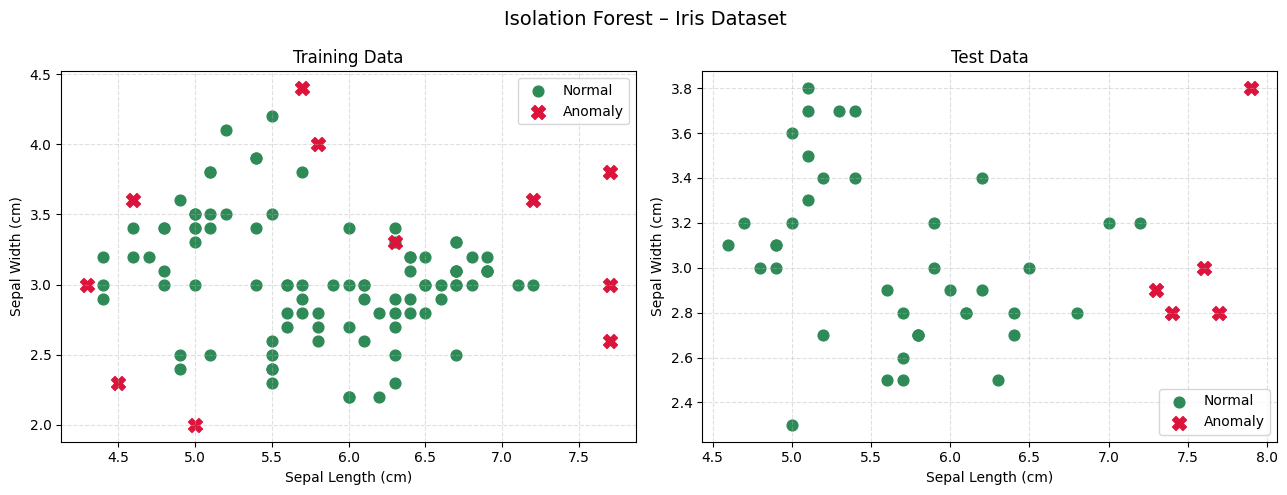

In [ ]:
import matplotlib.pyplot as plt

def create_scatter_plots(X1, y1, title1, X2, y2, title2):
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    for ax, X, y, title in [
        (axes[0], X1, y1, title1),
        (axes[1], X2, y2, title2)
    ]:
        ax.scatter(X[y == 1, 0], X[y == 1, 1],
                   color='seagreen', s=60, label='Normal')
        ax.scatter(X[y == -1, 0], X[y == -1, 1],
                   color='crimson', s=100, marker='X', label='Anomaly')
        ax.set_title(title)
        ax.set_xlabel("Sepal Length (cm)")
        ax.set_ylabel("Sepal Width (cm)")
        ax.legend()
        ax.grid(True, linestyle='--', alpha=0.4)

    plt.suptitle("Isolation Forest – Iris Dataset", fontsize=14)
    plt.tight_layout()
    plt.show()

create_scatter_plots(
    X_train, y_pred_train, "Training Data",
    X_test, y_pred_test, "Test Data"
)

5️⃣ One-Class SVM
Training & Prediction

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import svm

np.random.seed(0)

# Generate data
X = np.random.randn(100, 2)

# Inject outliers
X[:8] += 4

# Train One-Class SVM
clf = svm.OneClassSVM(
    nu=0.1,
    kernel="rbf",
    gamma=0.1
)
clf.fit(X)

# Predict
pred = clf.predict(X)

print(f"Points flagged as outliers: {np.sum(pred == -1)}")
print(f"Points flagged as normal: {np.sum(pred == 1)}")

Points flagged as outliers: 10
Points flagged as normal: 90


Decision Boundary Visualization


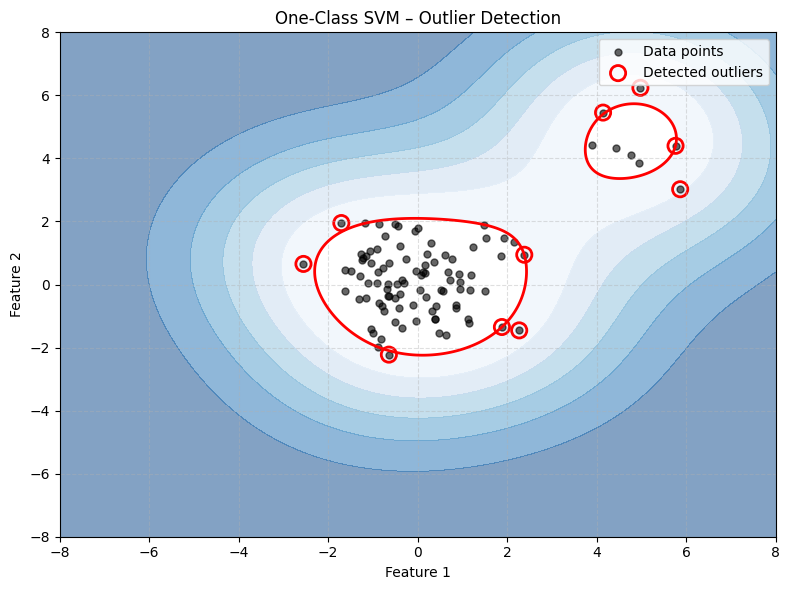

In [ ]:
# Create grid
xx, yy = np.meshgrid(
    np.linspace(-8, 8, 500),
    np.linspace(-8, 8, 500)
)

Z = clf.decision_function(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(8, 6))

# Outlier region
plt.contourf(
    xx, yy, Z,
    levels=np.linspace(Z.min(), 0, 7),
    cmap=plt.cm.Blues_r,
    alpha=0.5
)

# Decision boundary
plt.contour(xx, yy, Z, levels=[0], linewidths=2, colors='red')

# Data points
plt.scatter(X[:, 0], X[:, 1],
            color='black', s=25, alpha=0.6, label='Data points')

# Detected outliers
plt.scatter(X[pred == -1, 0], X[pred == -1, 1],
            s=120, edgecolors='red', facecolors='none',
            linewidths=2, label='Detected outliers')

plt.title("One-Class SVM – Outlier Detection")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()